In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/baseline_processed.csv")
df.head()

,priority,category,assigned_to,assignment_group,incident_state,opened_hour,opened_dayofweek,reassignment_count,reopen_count,sys_mod_count,task_duration_hours
0,2,41,0,44,0,-2.663182,-1.234195,-0.624480,-0.09195,-0.351920,10.216667
1,2,27,210,14,0,-1.925982,-1.234195,-0.001121,-0.09195,0.107860,29.200000
2,2,9,186,60,0,-1.434515,-1.234195,-0.624480,-0.09195,-0.122030,20.750000
3,2,52,27,15,0,-1.434515,-1.234195,-0.624480,-0.09195,-0.466865,53.466667
4,1,39,0,13,0,-1.434515,-1.234195,-0.001121,-0.09195,-0.007085,8.883333


In [2]:
df["task_duration_hours"].describe()

count    23362.000000
mean       178.171582
std        532.787772
min          0.000000
25%          0.416667
50%         22.100000
75%        148.479167
max       8070.166667
Name: task_duration_hours, dtype: float64

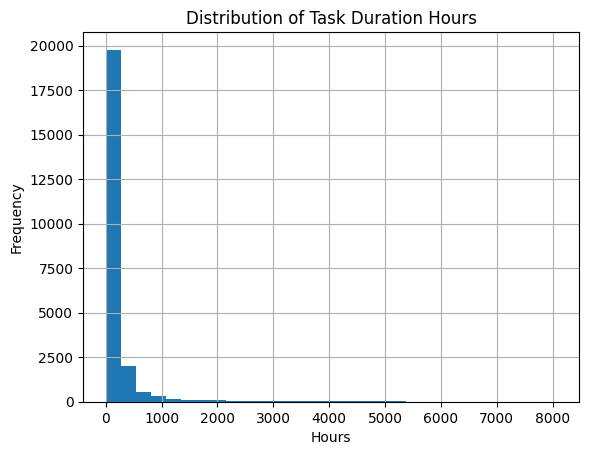

In [3]:
df["task_duration_hours"].hist(bins=30)
plt.title("Distribution of Task Duration Hours")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [5]:
df = pd.read_csv("../data/processed/baseline_processed.csv")
df.head()

,priority,category,assigned_to,assignment_group,incident_state,opened_hour,opened_dayofweek,reassignment_count,reopen_count,sys_mod_count,task_duration_hours
0,2,41,0,44,0,-2.663182,-1.234195,-0.624480,-0.09195,-0.351920,10.216667
1,2,27,210,14,0,-1.925982,-1.234195,-0.001121,-0.09195,0.107860,29.200000
2,2,9,186,60,0,-1.434515,-1.234195,-0.624480,-0.09195,-0.122030,20.750000
3,2,52,27,15,0,-1.434515,-1.234195,-0.624480,-0.09195,-0.466865,53.466667
4,1,39,0,13,0,-1.434515,-1.234195,-0.001121,-0.09195,-0.007085,8.883333


In [6]:
df.shape

(23362, 11)

In [7]:
df.columns.tolist()

['priority',
 'category',
 'assigned_to',
 'assignment_group',
 'incident_state',
 'opened_hour',
 'opened_dayofweek',
 'reassignment_count',
 'reopen_count',
 'sys_mod_count',
 'task_duration_hours']

In [8]:
df["task_duration_hours"].describe()

count    23362.000000
mean       178.171582
std        532.787772
min          0.000000
25%          0.416667
50%         22.100000
75%        148.479167
max       8070.166667
Name: task_duration_hours, dtype: float64

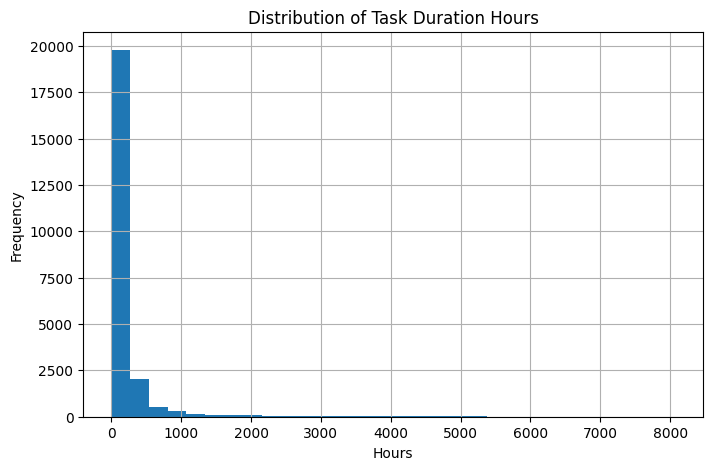

In [9]:
plt.figure(figsize=(8, 5))
df["task_duration_hours"].hist(bins=30)
plt.title("Distribution of Task Duration Hours")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.savefig("../results/figures/task_duration_distribution.png")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(columns=["task_duration_hours"])
y = df["task_duration_hours"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

mae = mean_absolute_error(y_test, predictions)
rmse = math.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 102.27973457852308
RMSE: 189.99350401809545


In [12]:
comparison_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": predictions
})

comparison_df.head(20)

,actual,predicted
0,30.250000,-20.213201
1,1366.716667,1847.866653
2,1.383333,106.595071
3,0.150000,40.491520
4,0.033333,-36.160977
5,1.600000,1610.382643
6,92.116667,566.113720
7,285.200000,345.311583
8,860.916667,770.506206
9,0.016667,-1.617487


In [13]:
comparison_df["residual"] = comparison_df["actual"] - comparison_df["predicted"]
comparison_df.head(20)

,actual,predicted,residual
0,30.250000,-20.213201,50.463201
1,1366.716667,1847.866653,-481.149986
2,1.383333,106.595071,-105.211738
3,0.150000,40.491520,-40.341520
4,0.033333,-36.160977,36.194311
5,1.600000,1610.382643,-1608.782643
6,92.116667,566.113720,-473.997054
7,285.200000,345.311583,-60.111583
8,860.916667,770.506206,90.410461
9,0.016667,-1.617487,1.634153


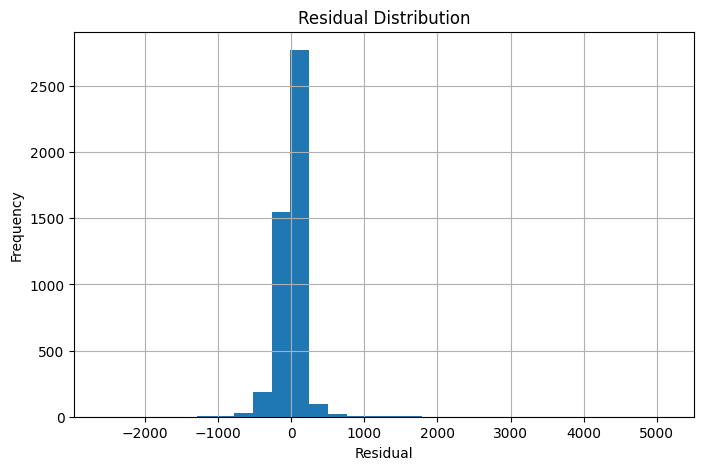

In [14]:
plt.figure(figsize=(8, 5))
comparison_df["residual"].hist(bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.savefig("../results/figures/residual_distribution.png")
plt.show()

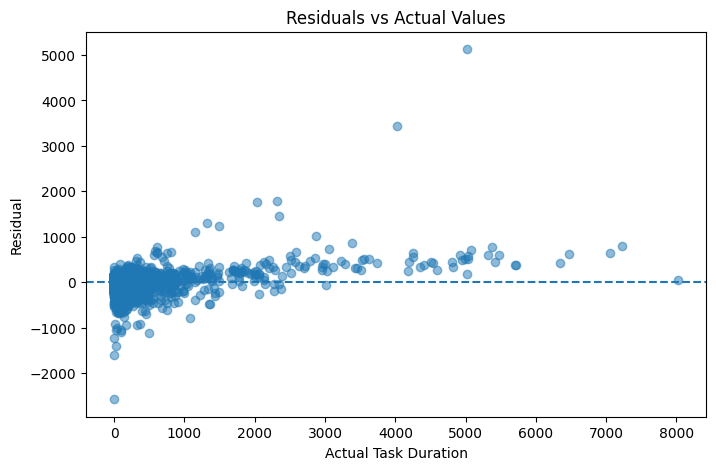

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(comparison_df["actual"], comparison_df["residual"], alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.title("Residuals vs Actual Values")
plt.xlabel("Actual Task Duration")
plt.ylabel("Residual")
plt.savefig("../results/figures/residuals_vs_actual.png")
plt.show()

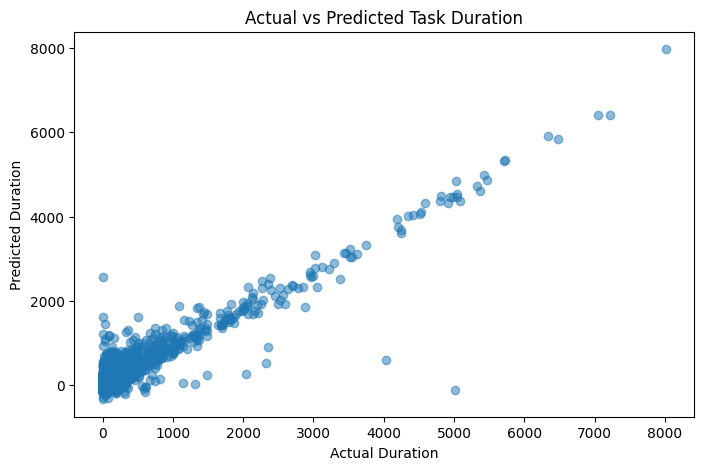

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(comparison_df["actual"], comparison_df["predicted"], alpha=0.5)
plt.title("Actual vs Predicted Task Duration")
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.savefig("../results/figures/actual_vs_predicted.png")
plt.show()

In [17]:
comparison_df["absolute_error"] = (comparison_df["actual"] - comparison_df["predicted"]).abs()
comparison_df.sort_values(by="absolute_error", ascending=False).head(20)

,actual,predicted,residual,absolute_error
531,5017.283333,-110.099359,5127.382692,5127.382692
4185,4028.166667,586.354793,3441.811874,3441.811874
486,0.100000,2576.654411,-2576.554411,2576.554411
3534,2320.716667,533.372483,1787.344183,1787.344183
3159,2038.450000,272.872498,1765.577502,1765.577502
5,1.600000,1610.382643,-1608.782643,1608.782643
839,2348.433333,894.924762,1453.508571,1453.508571
2679,29.316667,1439.325728,-1410.009061,1410.009061
675,1319.700000,16.480339,1303.219661,1303.219661
3678,1488.983333,246.456172,1242.527161,1242.527161


## Baseline Evaluation Findings

The baseline Linear Regression model provides an initial benchmark for predicting task duration, but several limitations are visible from the evaluation.

- The target distribution appears right-skewed, which suggests that most incidents are resolved relatively quickly while a smaller number take much longer.
- Residual analysis indicates that the model makes larger errors for higher-duration incidents.
- The actual vs predicted plot suggests that the model underfits the data and struggles to capture more complex workflow patterns.
- The baseline feature set is limited and does not fully represent operational dynamics.
- These findings justify the need for enhanced ETL, richer feature engineering, and stronger non-linear models in the next phase.

In [18]:
ls results/figures

ls: results/figures: No such file or directory


In [1]:
df.head()

NameError: name 'df' is not defined

In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv("../data/raw/workflow_tasks.csv")

In [4]:
df.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000047,Closed,False,1,0,8,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 9:52,6/3/2016 10:00
2,INC0000057,Closed,False,0,0,6,True,Caller 4416,Opened by 8,29/2/2016 06:10,...,False,Do Not Notify,Problem ID 2,?,?,?,code 10,Resolved by 5,1/3/2016 2:55,6/3/2016 3:00
3,INC0000060,Closed,False,0,0,3,True,Caller 4491,Opened by 180,29/2/2016 06:38,...,False,Do Not Notify,?,?,?,?,code 3,Resolved by 113,2/3/2016 12:06,7/3/2016 13:00
4,INC0000062,Closed,False,1,0,7,False,Caller 3765,Opened by 180,29/2/2016 06:58,...,False,Do Not Notify,?,?,?,?,code 7,Resolved by 62,29/2/2016 15:51,5/3/2016 16:00


In [5]:
df.columns.tolist()

['number',
 'incident_state',
 'active',
 'reassignment_count',
 'reopen_count',
 'sys_mod_count',
 'made_sla',
 'caller_id',
 'opened_by',
 'opened_at',
 'sys_created_by',
 'sys_created_at',
 'sys_updated_by',
 'sys_updated_at',
 'contact_type',
 'location',
 'category',
 'subcategory',
 'u_symptom',
 'cmdb_ci',
 'impact',
 'urgency',
 'priority',
 'assignment_group',
 'assigned_to',
 'knowledge',
 'u_priority_confirmation',
 'notify',
 'problem_id',
 'rfc',
 'vendor',
 'caused_by',
 'closed_code',
 'resolved_by',
 'resolved_at',
 'closed_at']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24918 entries, 0 to 24917
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   number                   24918 non-null  object
 1   incident_state           24918 non-null  object
 2   active                   24918 non-null  bool  
 3   reassignment_count       24918 non-null  int64 
 4   reopen_count             24918 non-null  int64 
 5   sys_mod_count            24918 non-null  int64 
 6   made_sla                 24918 non-null  bool  
 7   caller_id                24918 non-null  object
 8   opened_by                24918 non-null  object
 9   opened_at                24918 non-null  object
 10  sys_created_by           24918 non-null  object
 11  sys_created_at           24918 non-null  object
 12  sys_updated_by           24918 non-null  object
 13  sys_updated_at           24918 non-null  object
 14  contact_type             24918 non-nul